# Evaluation

In [28]:
%load_ext autoreload
%autoreload 2
from typing import Literal

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_context("notebook", font_scale=0.1)
plt.style.use("default")
plt.rc("figure", dpi=150)
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8

from evaluate import PlottingWrapper

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helpers

In [29]:
plotting_wrapper = PlottingWrapper()

In [4]:
# extraction_columns = [f"{x}_option" for x in answer_columns]

In [5]:
length_dynamic_cols = [
    "base",
    "dynamic_short",
    "dynamic_long",
    "helpful_answer_option",
    "static_short_answer_option",
    "static_long_answer_option",
    "beginner_teacher_answer_option",
    "intermediate_teacher_answer_option",
    "expert_teacher_answer_option",
]

# 1. persona vs. baseline
# 2. measuring effects of properties with regression
# 3. static vs. dynamic
# for discussion: findings between open and closed
# find title!!
# no acknowledgments
# next meeting: 14.01.2025 @ 14:00

In [30]:
import pandas as pd
from pathlib import Path

input_dir = Path("data/evaluation/")

dfs = []
for file in input_dir.iterdir():
    dataset_name = file.stem
    if file.suffix != ".csv" or "flores" in dataset_name:
        continue
    raw_df = pd.read_csv(file, index_col=0)
    raw_df = raw_df.rename(columns={"iso_639_3": "category", "subject": "category"})
    if "alpaca" in dataset_name:
        raw_df["score"] = (raw_df["score"] >= 1.5).astype(int)

    raw_df.insert(0, "dataset", dataset_name)
    if "category" in raw_df.columns:
        raw_df["split"] = raw_df["dataset"] + raw_df["category"]
    else:
        raw_df["split"] = raw_df["dataset"]

    dfs.append(raw_df)
df = pd.concat(dfs)
length_base_df = df.copy()

flores_df = pd.read_csv("data/evaluation/flores.csv", index_col=0)

In [31]:
df["persona"] = df["persona"].str.replace("dynamic", "d")
df["persona"] = df["persona"].str.replace("static", "s")
df["persona"] = df["persona"].str.replace("_teacher", "")
df = df[df["persona"] != "helpful"]

In [32]:
_PERSONA_ORDERING = [
    "base", "s_short", "s_medium", "s_long",
    "d_short", "d_medium", "d_long",
    "beginner", "intermediate", "expert"
]
_order_map = {v: i for i, v in enumerate(_PERSONA_ORDERING)}

In [33]:
def compute_gains(data):
    for persona_ in _PERSONA_ORDERING:
        data[persona_] = data[persona_] - data["no"]
    data = data.drop(index="no")
    return data[_PERSONA_ORDERING]

In [81]:
tests_baseline_df = pd.read_csv("data/evaluation/tests/results_baseline.csv", index_col=0)
tests_length_df = pd.read_csv("data/evaluation/tests/results_length.csv", index_col=0)
tests_teacher_df = pd.read_csv("data/evaluation/tests/results_teacher.csv", index_col=0)
tests_dynamic_df = pd.read_csv("data/evaluation/tests/results_static_vs_dynamic.csv", index_col=0)
def print_sig(sig_df, group_col):
    sig_df = sig_df.sort_values(by="dataset")
    for d_name, sig_group_df in sig_df.groupby(group_col):
        print(f" === {d_name} ===")
        sig = sig_group_df[sig_group_df["pvalue"] < 0.05]
        for row in sig.itertuples():
            if row.term == "Intercept" or "llama" in row.term or "wen" in row.term or "gpt" in row.term or "gemma" in row.term\
                    or "1/2" in row.term or "helpful" in row.term or "0" in row.term or "1" in row.term or "2" in row.term:
                continue
            print(f"Persona {row.term:<20} p-val {row.pvalue:.3f} coef {row.coef:.3f}")
            if hasattr(row, "mode"):
                print(row.mode)

# 1. Persona vs. Baseline

## Aggregate Performance Across all Datasets (except flores) and Models

In [9]:
aggregate_df = df.copy()
aggregate_df = aggregate_df.groupby(["persona"])["score"].mean()
aggregate_df = compute_gains(aggregate_df)

<Axes: xlabel='score', ylabel='persona'>

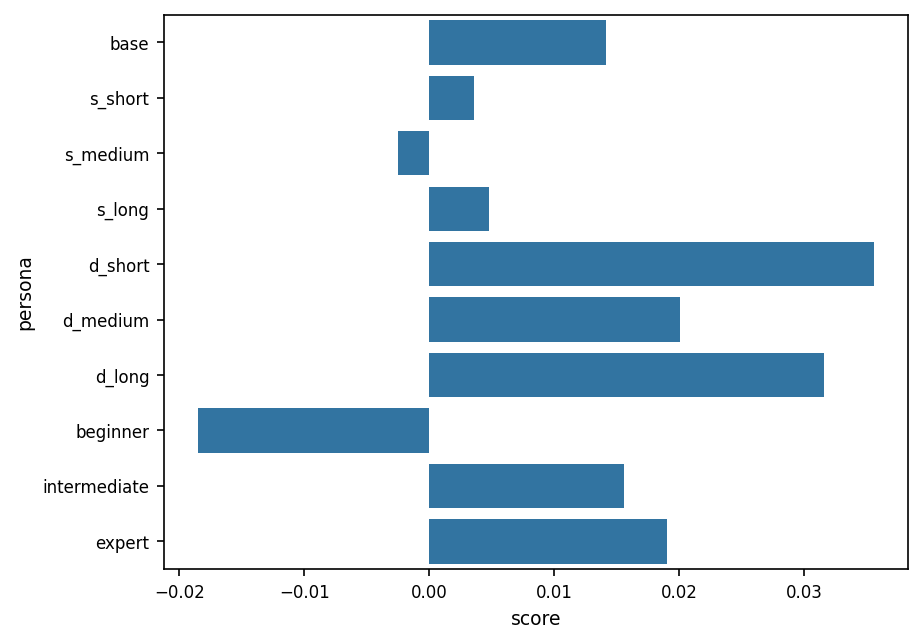

In [10]:
sns.barplot(aggregate_df, orient="h")

- Across all datasets, there seems to be a positive impact of dynamic personas
- Dynamic ones seem better than static
- Longer personas not necessarily better
- Teacher personas follow intuitive trend

## Performance By Dataset

In [11]:
dataset_df = df.copy()
dataset_df = dataset_df.groupby(["dataset", "persona"], as_index=False)["score"].mean()

parts = []
for dataset_name, group_df in dataset_df.groupby("dataset", sort=False):
    ref = group_df.loc[group_df["persona"] == "no", "score"]

    ref_score = ref.iloc[0]
    group_df["reference_score"] = ref_score
    group_df["gain"] = group_df["score"] - ref_score
    parts.append(group_df)

dataset_df = pd.concat(parts, ignore_index=True)
dataset_df = dataset_df.sort_values("persona", key=lambda s: s.map(_order_map))
dataset_df = dataset_df[dataset_df["persona"] != "no"]

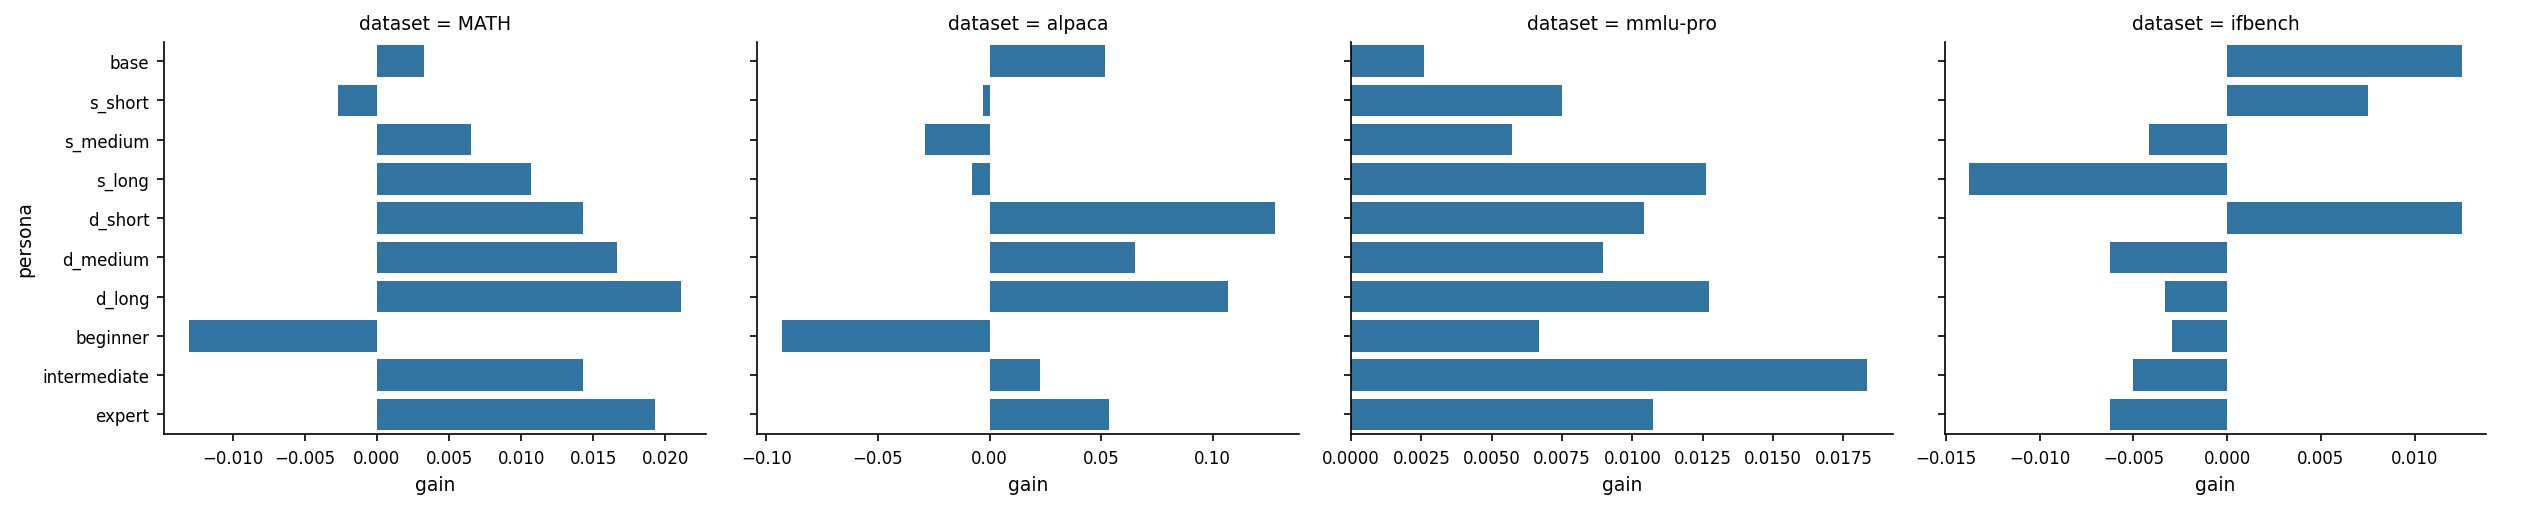

In [12]:
plot_kwargs = {"height": 3.5, "aspect": 1.2, "width": 0.8}
sns.catplot(dataset_df, col="dataset", y="persona", kind="bar", x="gain", orient="h", sharex=False,
            **plot_kwargs)

- if we split up the comparison dataset-wise, the outcome changes a bit: it is dataset-dependent
- one some datasets, the impact is more positive: e.g. mmlu-pro and MATH
- on some it seems worse: e.g. ifbench
- there is also some variability in the performance impact per-dataset, e.g. on alpaca, dynami ones have a very large impact, on mmlu-pro not so much

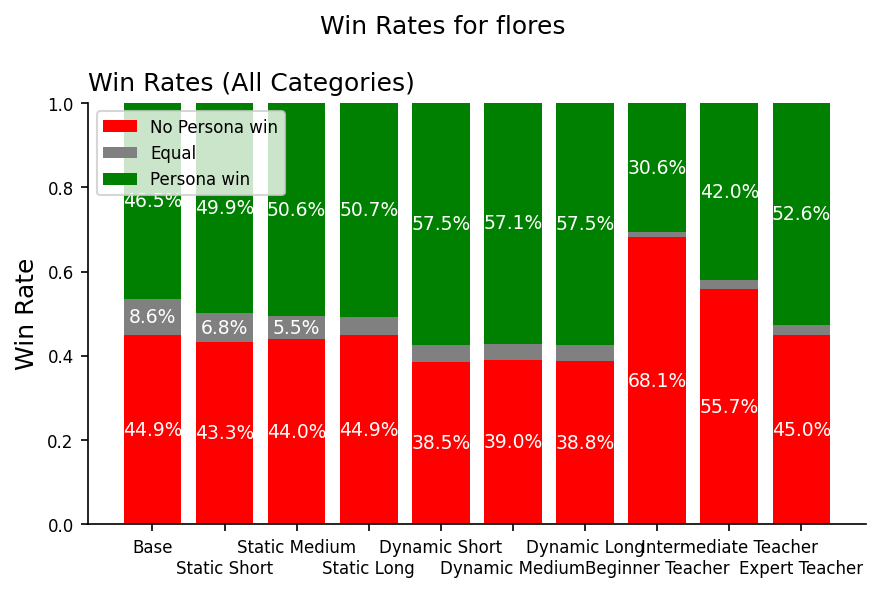

In [19]:
plotting_wrapper.create_overall_stacked_barchart("flores")

In [21]:
dataset_results = tests_baseline_df[tests_baseline_df["category"].isna()]
print_sig(dataset_results, "dataset")

 === MATH ===
Persona expert_teacher       p-val 0.010 coef 0.207
Persona dynamic_medium       p-val 0.025 coef 0.178
Persona dynamic_long         p-val 0.005 coef 0.225
 === alpaca ===
Persona static_medium        p-val 0.000 coef -0.035
Persona expert_teacher       p-val 0.000 coef 0.045
Persona dynamic_medium       p-val 0.000 coef 0.057
Persona dynamic_long         p-val 0.000 coef 0.098
Persona beginner_teacher     p-val 0.000 coef -0.095
Persona base                 p-val 0.000 coef 0.046
Persona dynamic_short        p-val 0.000 coef 0.117
 === flores ===
Persona static_short         p-val 0.001 coef 0.102
Persona static_long          p-val 0.004 coef 0.089
Persona static_medium        p-val 0.001 coef 0.103
Persona dynamic_long         p-val 0.000 coef 0.357
Persona dynamic_medium       p-val 0.000 coef 0.344
Persona dynamic_short        p-val 0.000 coef 0.361
Persona beginner_teacher     p-val 0.000 coef -0.850
Persona intermediate_teacher p-val 0.000 coef -0.314
Persona expert

- some datasets benefit more than others (e.g. mmlu-pro)
- ifbench seems completely agnostic to personas
- flores on the other hand seems very good

## Performance By Dataset Subcategory

In [22]:
category_df = df.copy()
category_df = category_df.groupby(["dataset", "category", "persona"], as_index=False)["score"].mean()

parts = []
for dataset_name, group_df in category_df.groupby("category", sort=False):
    ref = group_df.loc[group_df["persona"] == "no", "score"]

    ref_score = ref.iloc[0]
    group_df["reference_score"] = ref_score
    group_df["gain"] = group_df["score"] - ref_score
    parts.append(group_df)

category_df = pd.concat(parts, ignore_index=True)
category_df = category_df.sort_values("persona", key=lambda s: s.map(_order_map))
category_df = category_df[category_df["persona"] != "no"]

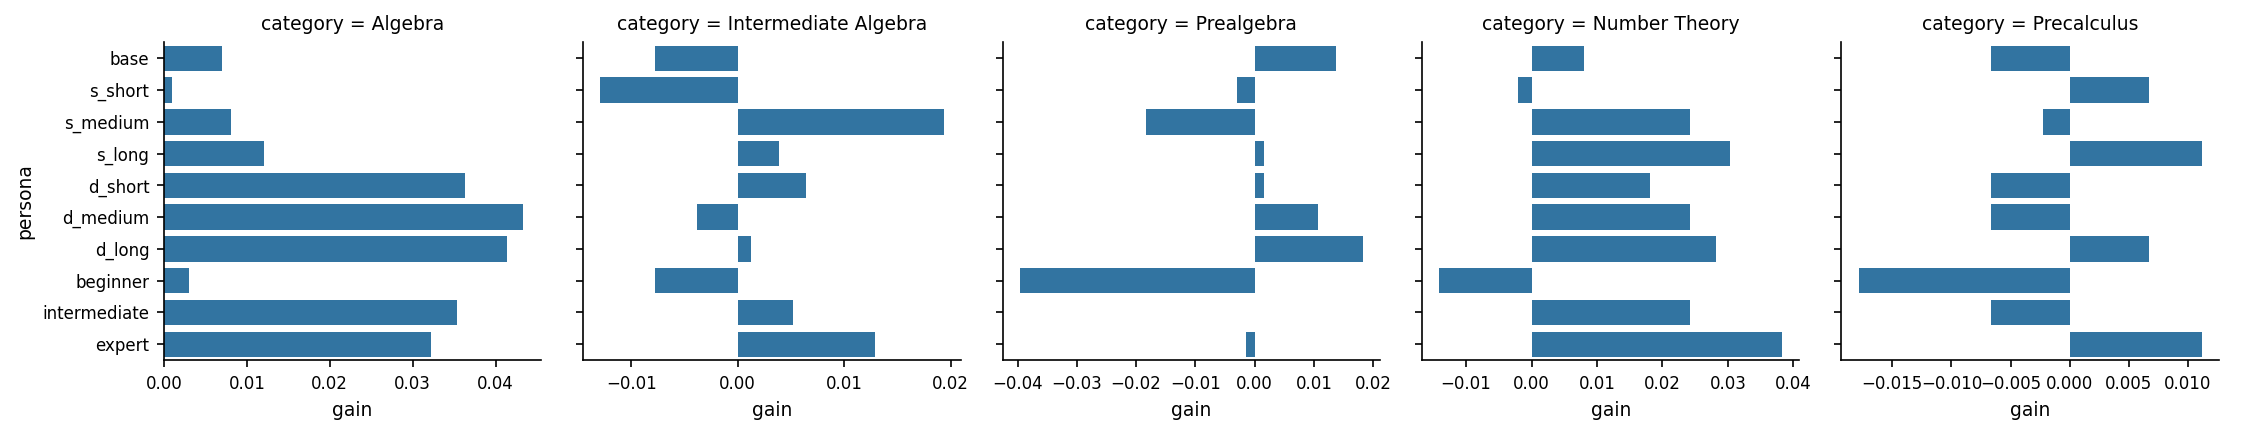

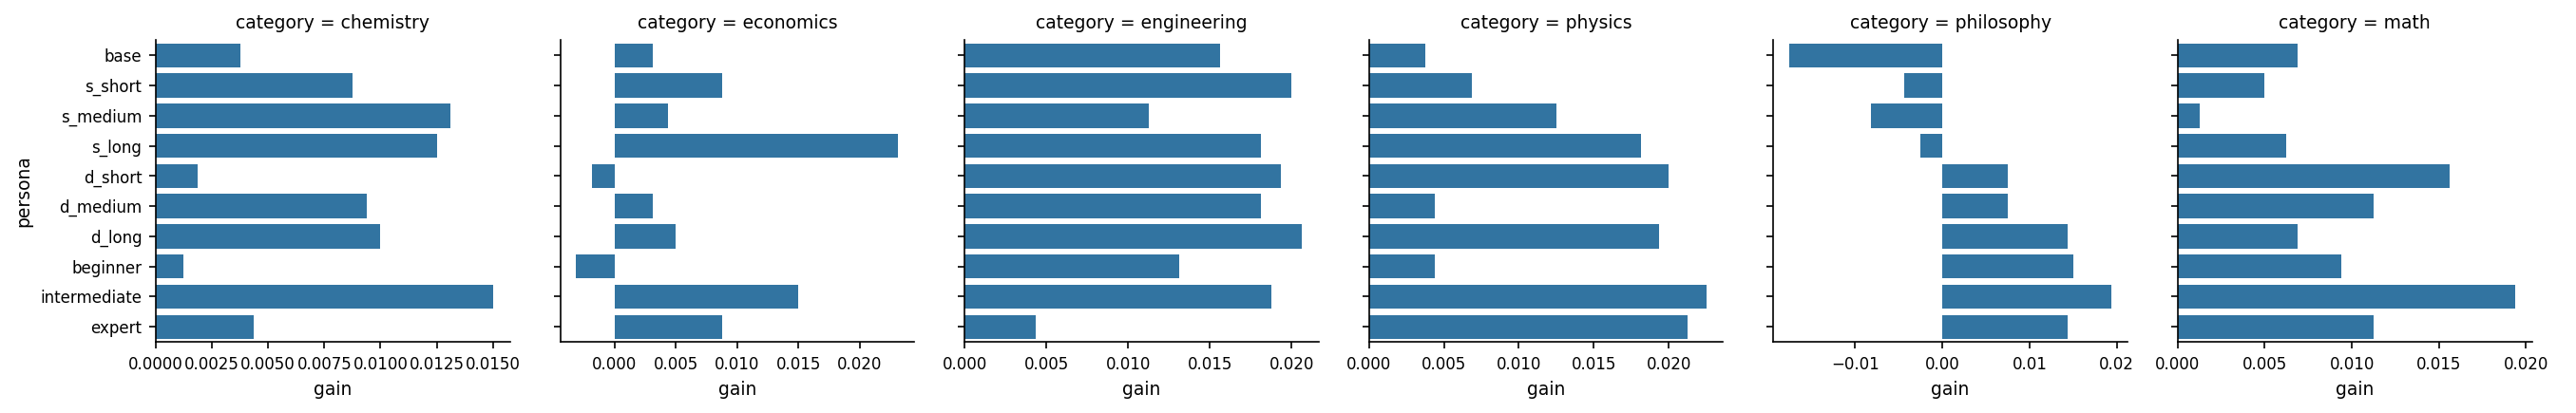

In [23]:
for dataset, sub_df in category_df.groupby("dataset"):
    sns.catplot(sub_df, col="category", y="persona", kind="bar", x="gain", orient="h", sharex=False, height=3)

- similar to datasets as a whole, the impact of personas also depends on subcategories

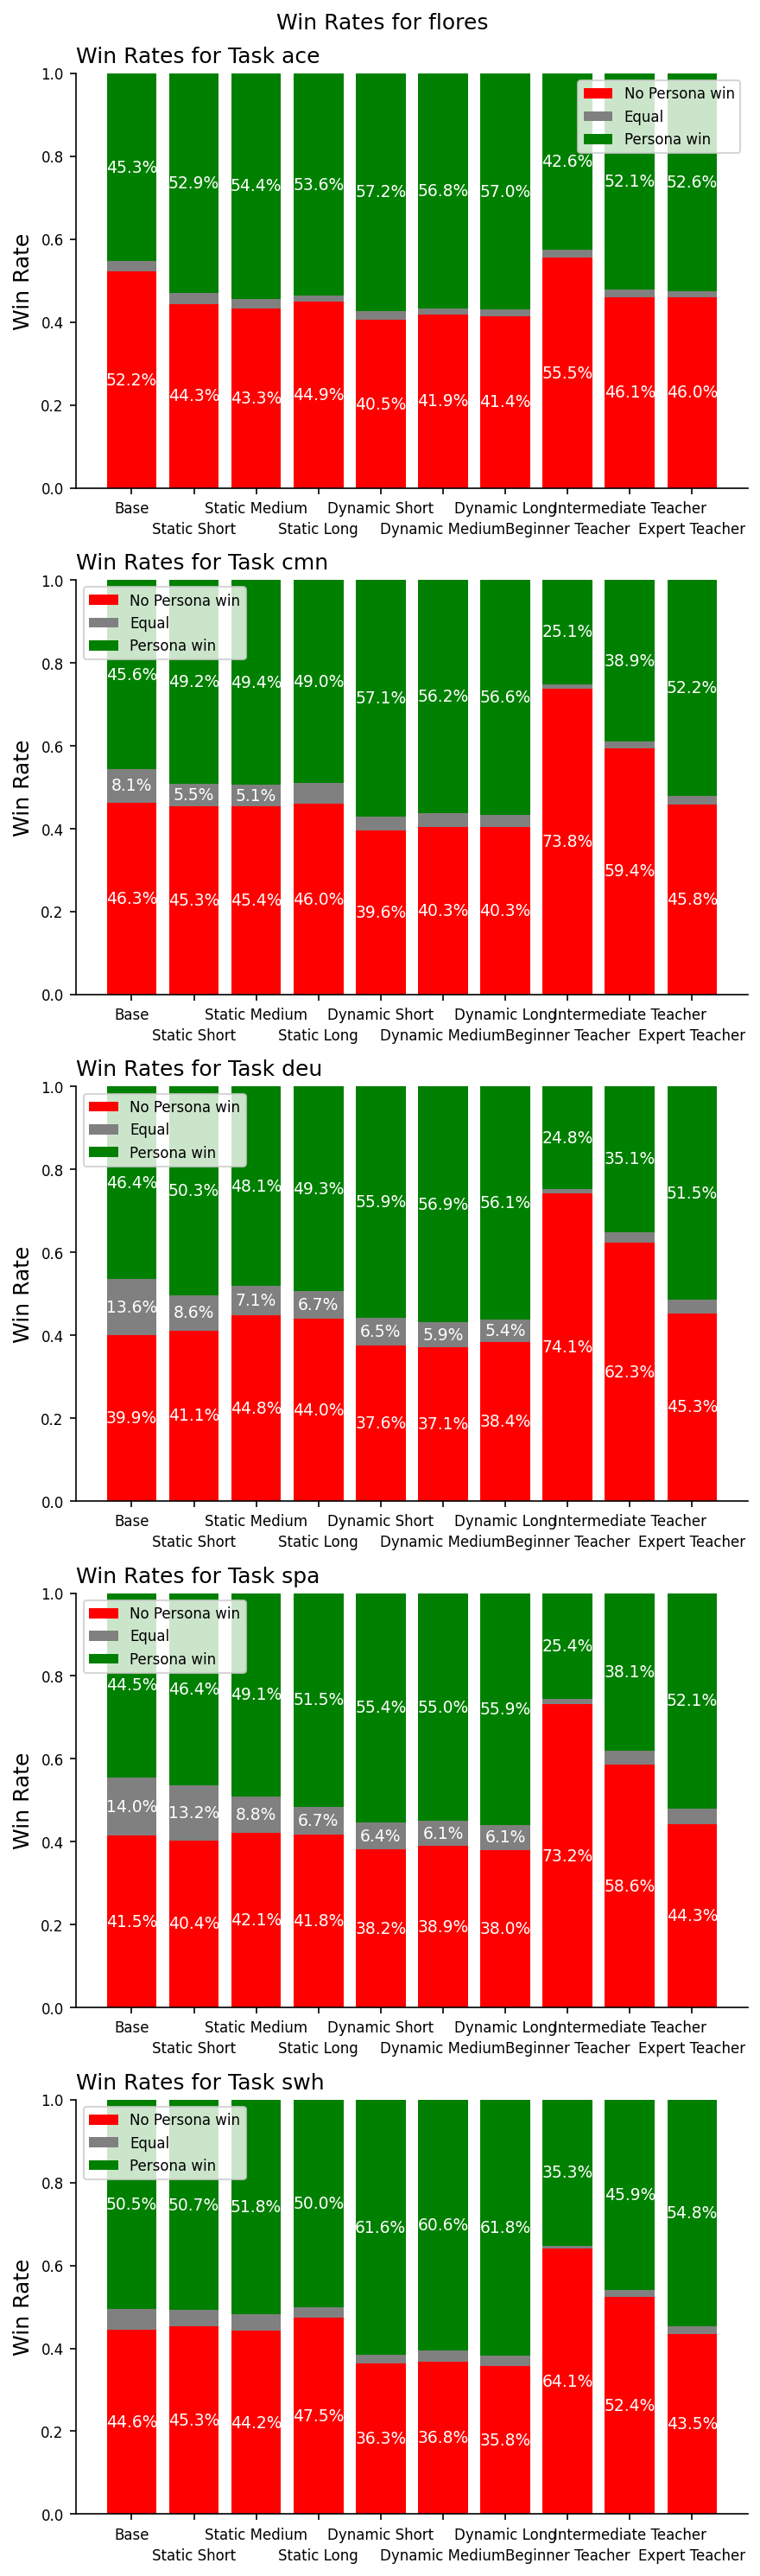

In [25]:
plotting_wrapper.create_stacked_barchart_plots("flores", "iso_639_3")

In [24]:
print_sig(tests_baseline_df, "category")

 === Algebra ===
Persona intermediate_teacher p-val 0.011 coef 0.375
Persona expert_teacher       p-val 0.019 coef 0.343
Persona dynamic_short        p-val 0.009 coef 0.385
Persona dynamic_medium       p-val 0.002 coef 0.459
Persona dynamic_long         p-val 0.003 coef 0.438
 === Intermediate Algebra ===
 === Number Theory ===
Persona expert_teacher       p-val 0.027 coef 0.516
 === Prealgebra ===
Persona beginner_teacher     p-val 0.028 coef -0.371
 === Precalculus ===
 === ace ===
Persona intermediate_teacher p-val 0.000 coef 0.260
Persona expert_teacher       p-val 0.000 coef 0.272
Persona dynamic_short        p-val 0.000 coef 0.476
Persona dynamic_medium       p-val 0.000 coef 0.442
Persona dynamic_long         p-val 0.000 coef 0.456
Persona static_long          p-val 0.000 coef 0.313
Persona static_medium        p-val 0.000 coef 0.360
Persona static_short         p-val 0.000 coef 0.310
 === chemistry ===
 === cmn ===
Persona 0/1                  p-val 0.011 coef 0.160
Persona int

- outcome also quite sensitive to categories
- dynamic persona even stronger than before
- teachers follow mostly positive trend
- but partially, results are not significant anymore


# 2. Comparison by length

In [8]:
from evaluate import prepare_length

dfs = []
for mode in ["static", "dynamic"]:
    mode: Literal["static", "dynamic"] = mode   # to silence warning
    length_df = prepare_length(length_base_df, mode)
    length_df["mode"] = mode
    dfs.append(length_df)
length_df = pd.concat(dfs)

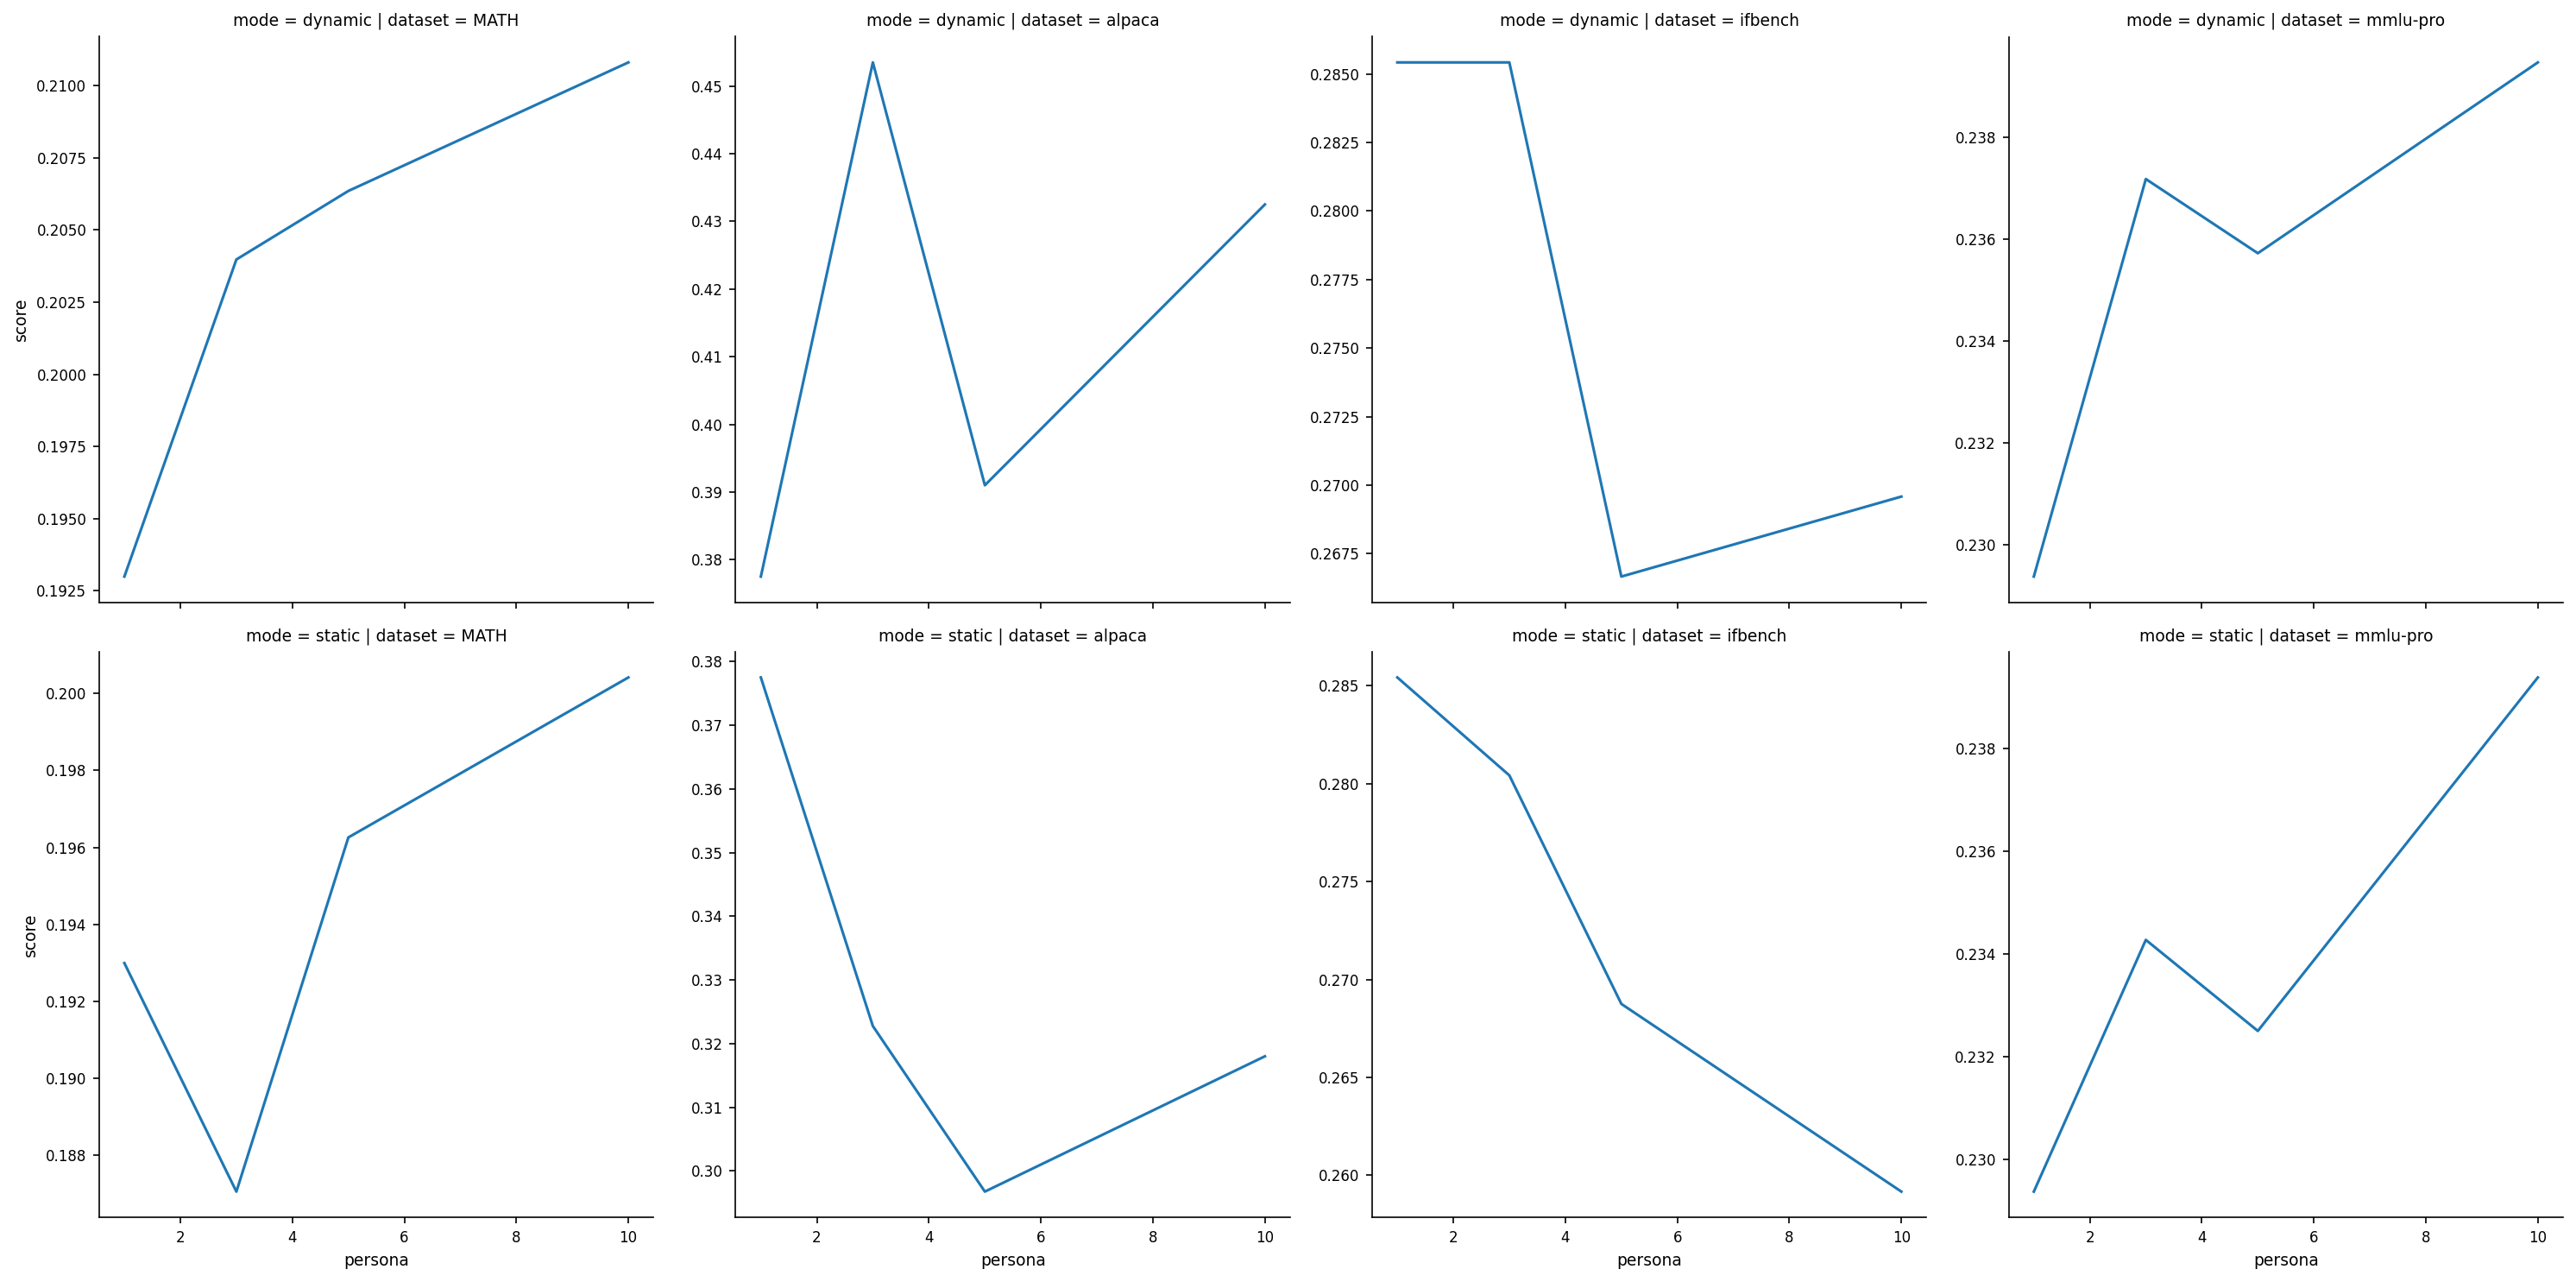

In [13]:
d_len_df = length_df.groupby(["dataset", "mode", "persona"], as_index=False)["score"].mean()
facet_kw = {"sharey": False}
sns.relplot(d_len_df, x="persona", y="score", row="mode", col="dataset", kind="line", facet_kws=facet_kw)

In [39]:
dataset_len_results = tests_length_df[tests_length_df["category"].isna()]
print_sig(dataset_len_results, "dataset")

 === MATH ===
Persona length               p-val 0.032 coef 0.018
dynamic
 === alpaca ===
Persona length               p-val 0.000 coef 0.003
dynamic
Persona length               p-val 0.000 coef -0.005
static
 === flores ===
Persona length               p-val 0.000 coef 0.031
dynamic
Persona length               p-val 0.026 coef 0.007
static
 === ifbench ===
Persona length               p-val 0.021 coef -0.017
static
 === mmlu-pro ===


- ifbench showed mostly negative trends before, so it is expected that the length will also have a negative impact
- MATH and mmlu-pro seem most intuitive, though mmlu-pro does not have a statistically significant impact
- very little strictly monotonic cases

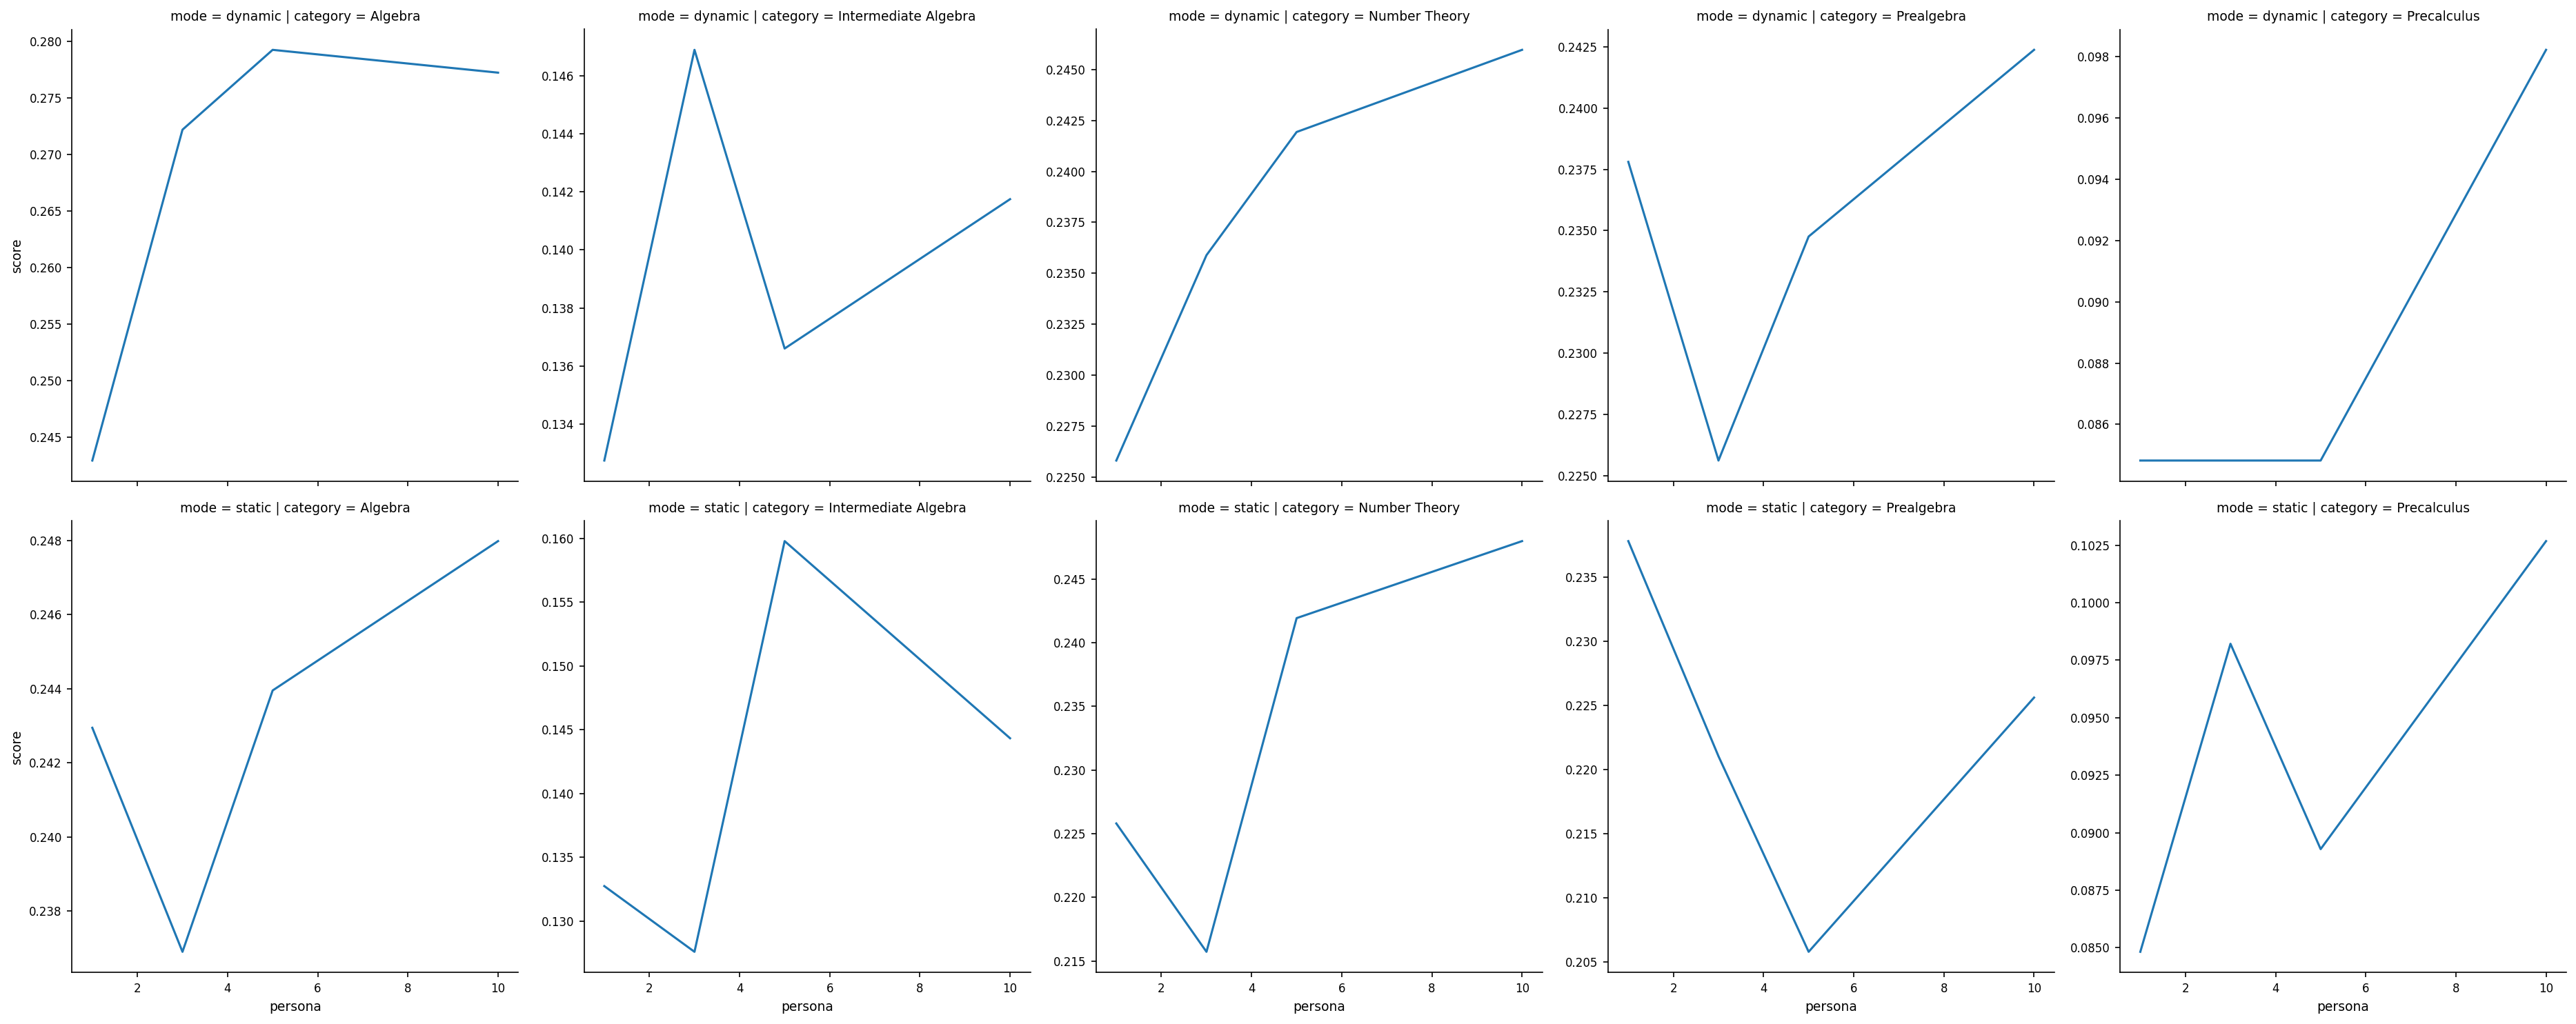

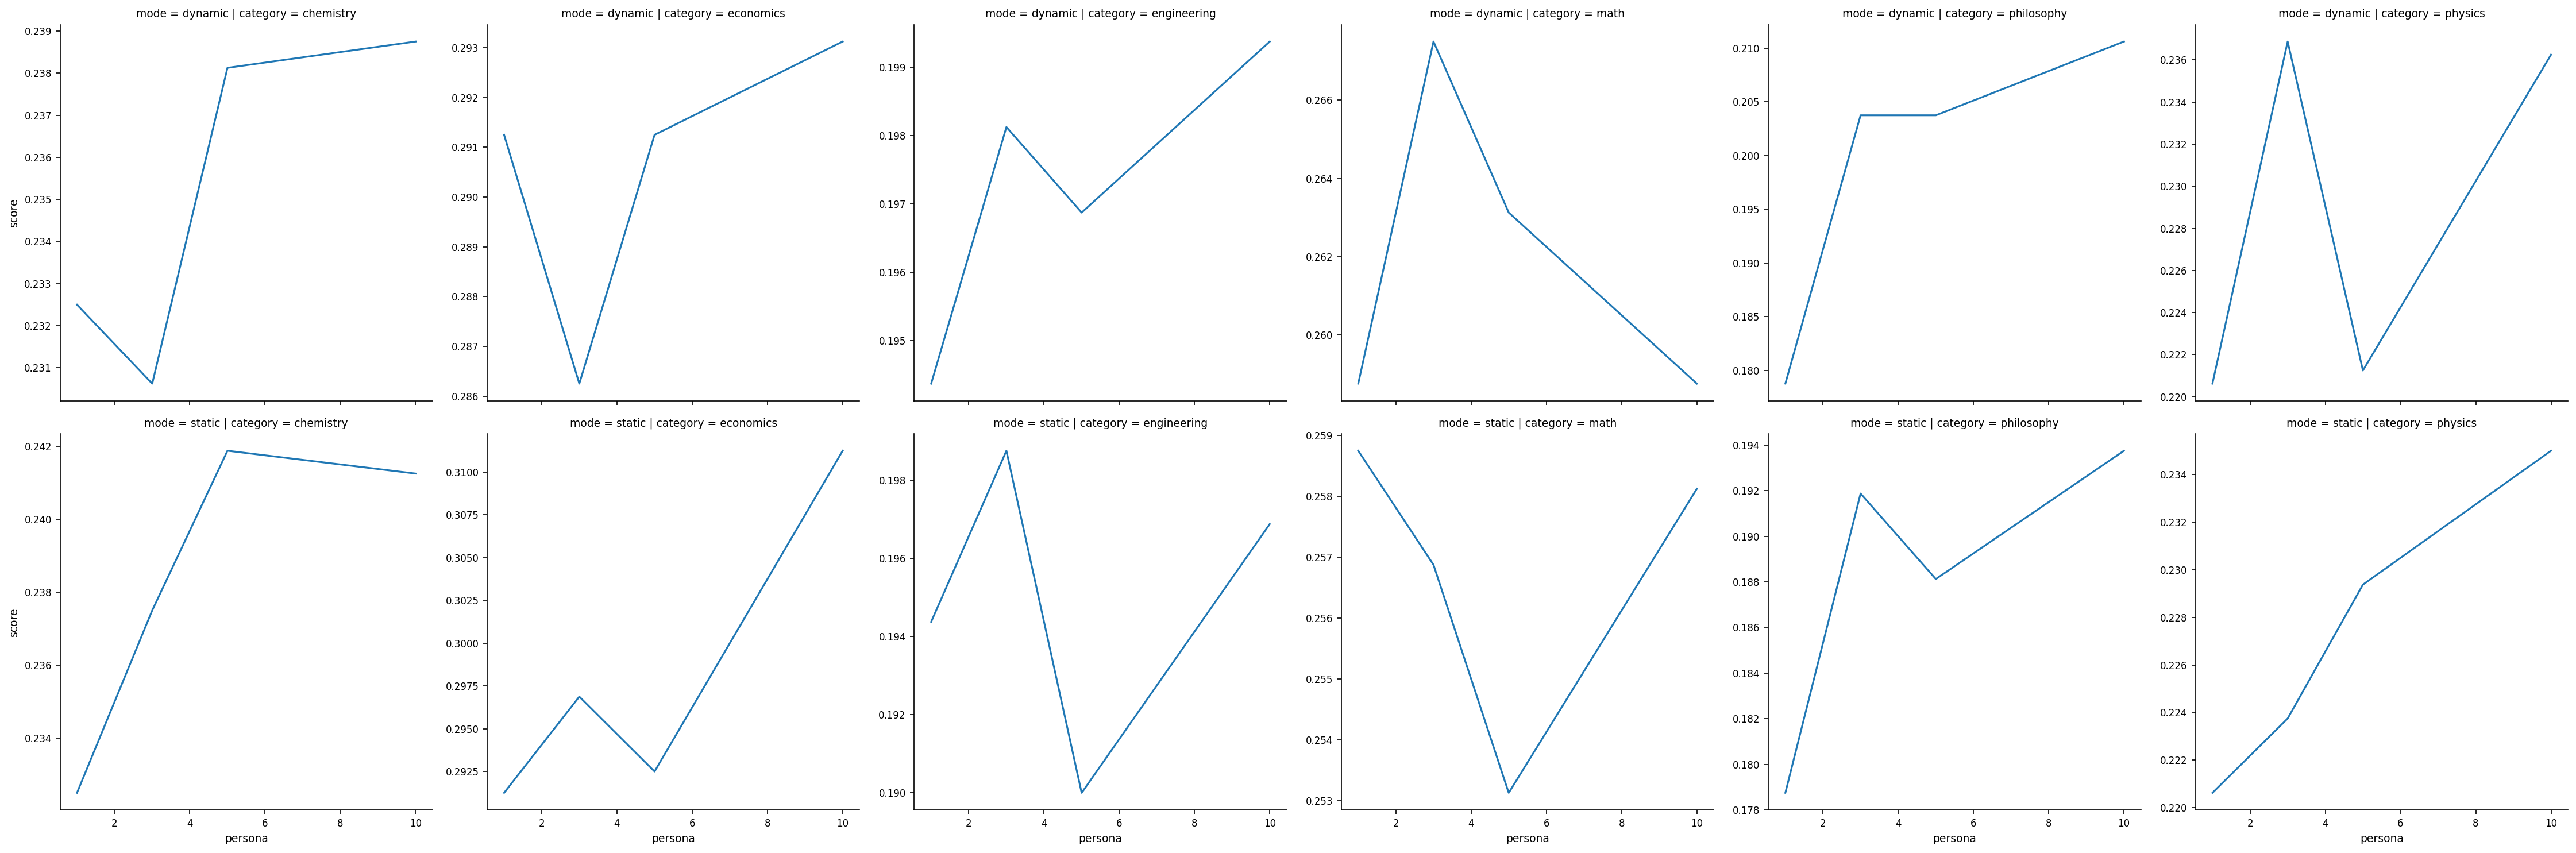

In [16]:
d_cat_df = length_df.groupby(["dataset", "category", "mode", "persona"], as_index=False)["score"].mean()

facet_kw = {"sharey": False}
d_cat_df = d_cat_df.dropna()
for dataset, group_df in d_cat_df.groupby("dataset"):
    sns.relplot(group_df, x="persona", y="score", row="mode", col="category", kind="line", facet_kws=facet_kw)

In [40]:
print_sig(cat_results, "category")

 === Algebra ===
Persona length               p-val 0.038 coef 0.031
dynamic
 === Intermediate Algebra ===
 === Number Theory ===
 === Prealgebra ===
 === Precalculus ===
 === ace ===
Persona length               p-val 0.000 coef 0.038
dynamic
Persona length               p-val 0.000 coef 0.027
static
 === chemistry ===
 === cmn ===
Persona length               p-val 0.000 coef 0.029
dynamic
 === deu ===
Persona length               p-val 0.003 coef 0.022
dynamic
 === economics ===
 === engineering ===
 === math ===
 === philosophy ===
Persona length               p-val 0.026 coef 0.024
dynamic
 === physics ===
 === spa ===
Persona length               p-val 0.000 coef 0.028
dynamic
Persona length               p-val 0.033 coef 0.015
static
 === swh ===
Persona length               p-val 0.000 coef 0.037
dynamic


- only clear trend observable is that dynamic personas seem very strong on flores+
- also: it seems like the medium length persona is always quite bad, while longer and shorter ones are better

# 3. Comparison by expertise

In [48]:
from evaluate import prepare_teacher

teacher_df = prepare_teacher(length_base_df)

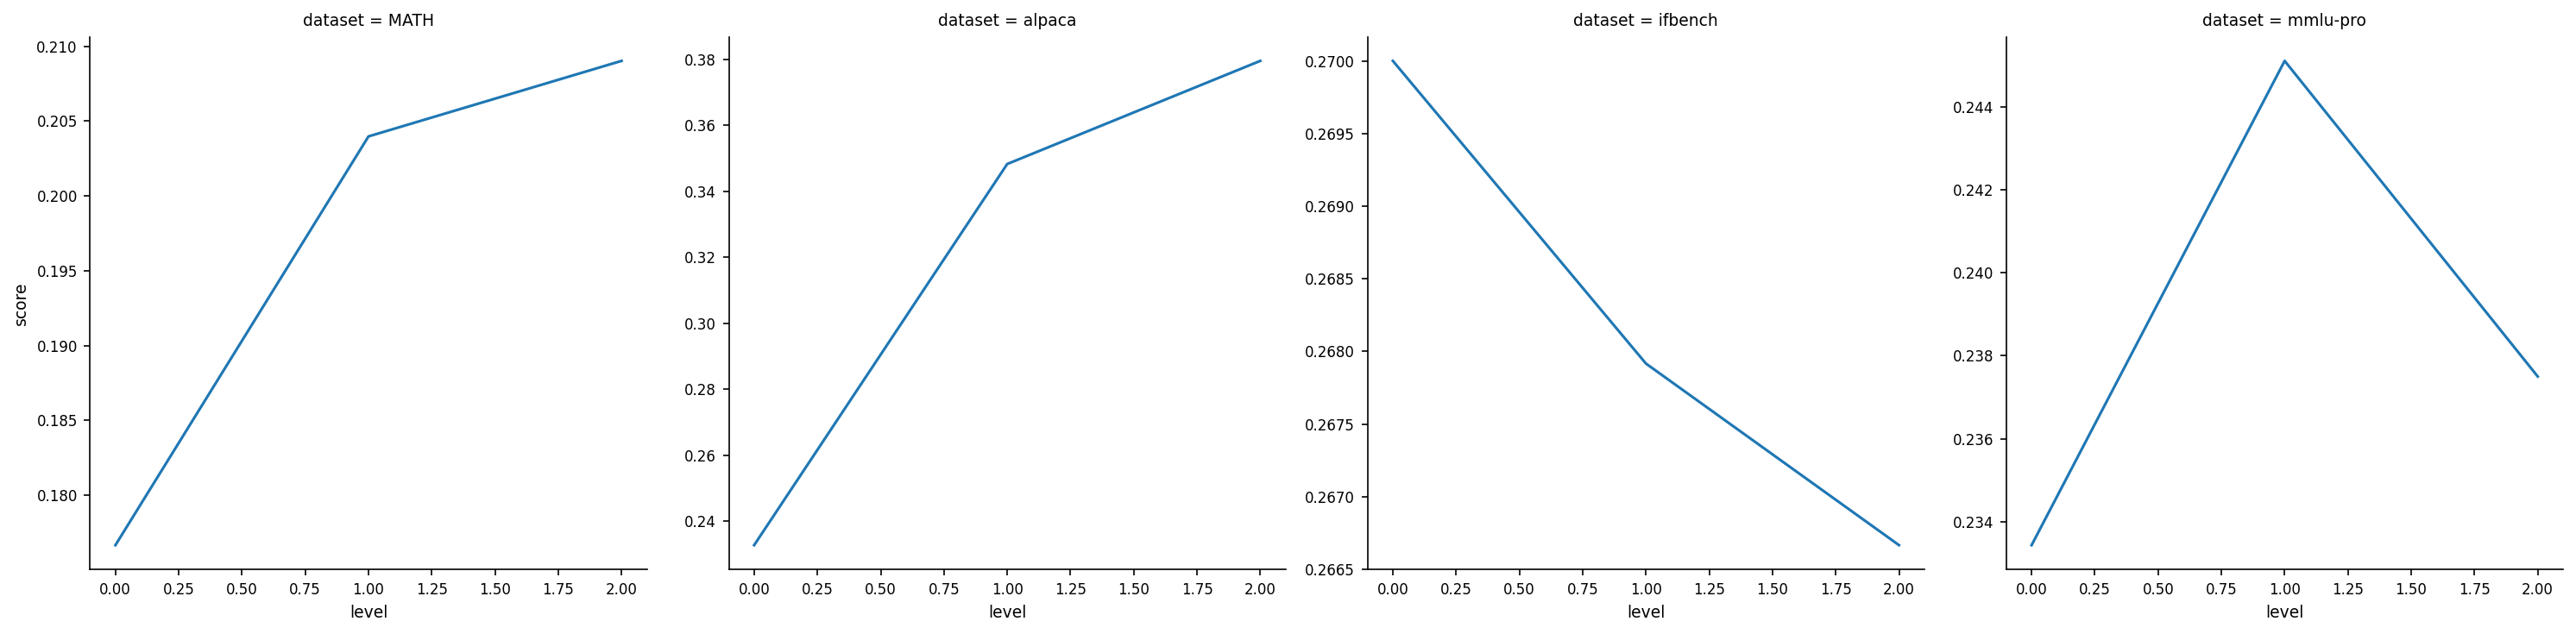

In [51]:
d_teacher_df = teacher_df.groupby(["dataset", "level"], as_index=False)["score"].mean()
facet_kw = {"sharey": False}
sns.relplot(d_teacher_df, x="level", y="score", col="dataset", kind="line", facet_kws=facet_kw)

In [52]:
dataset_teacher_results = tests_teacher_df[tests_teacher_df["category"].isna()]
print_sig(dataset_teacher_results, "dataset")

 === MATH ===
Persona level                p-val 0.000 coef 0.172
 === alpaca ===
Persona level                p-val 0.000 coef 0.070
 === flores ===
Persona level                p-val 0.000 coef 0.489
 === ifbench ===
 === mmlu-pro ===


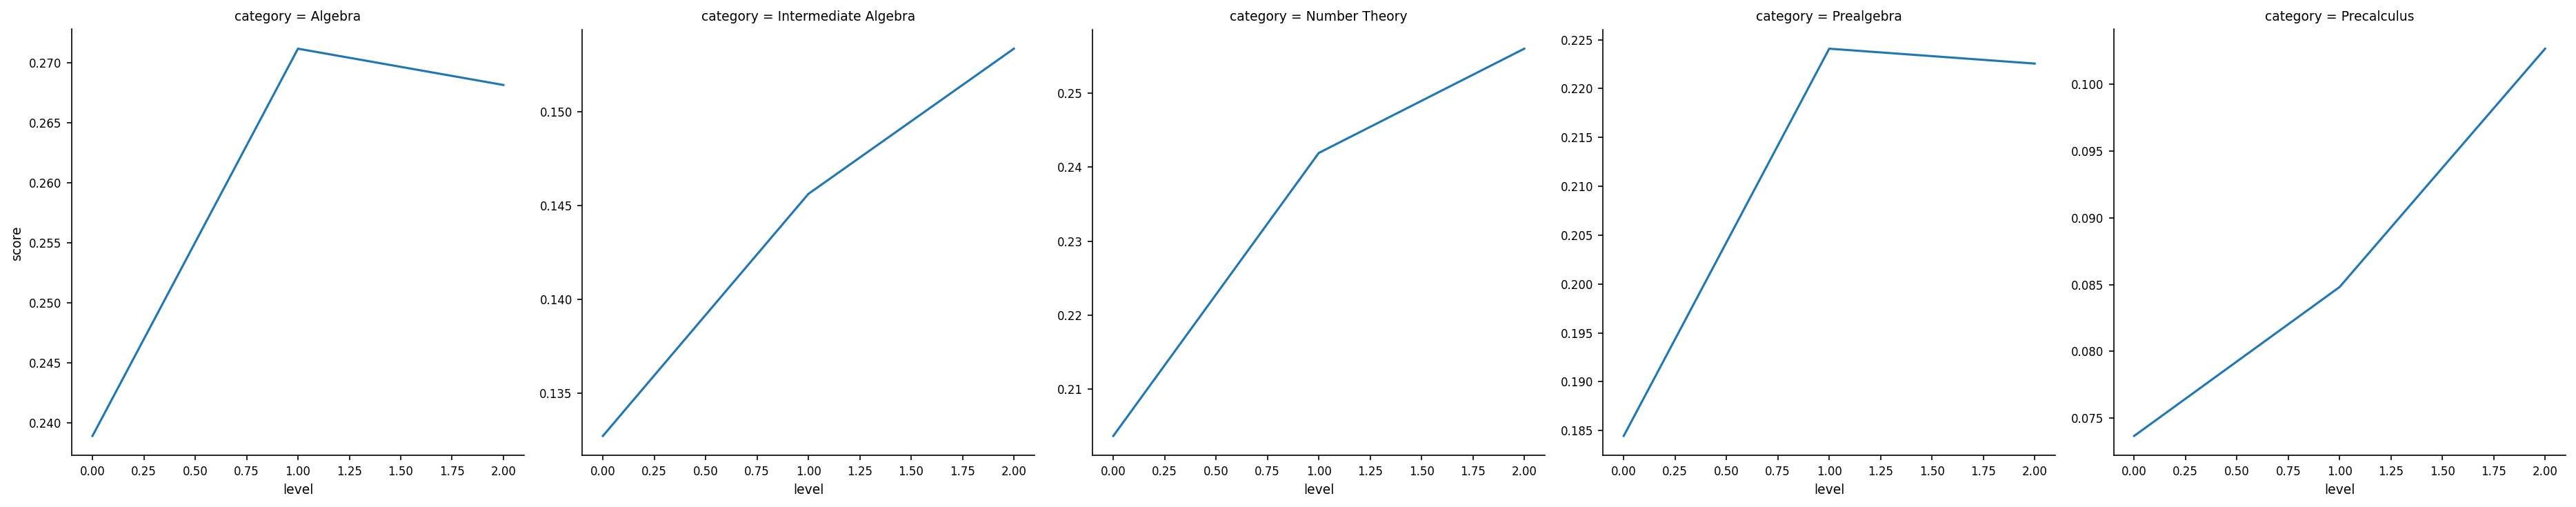

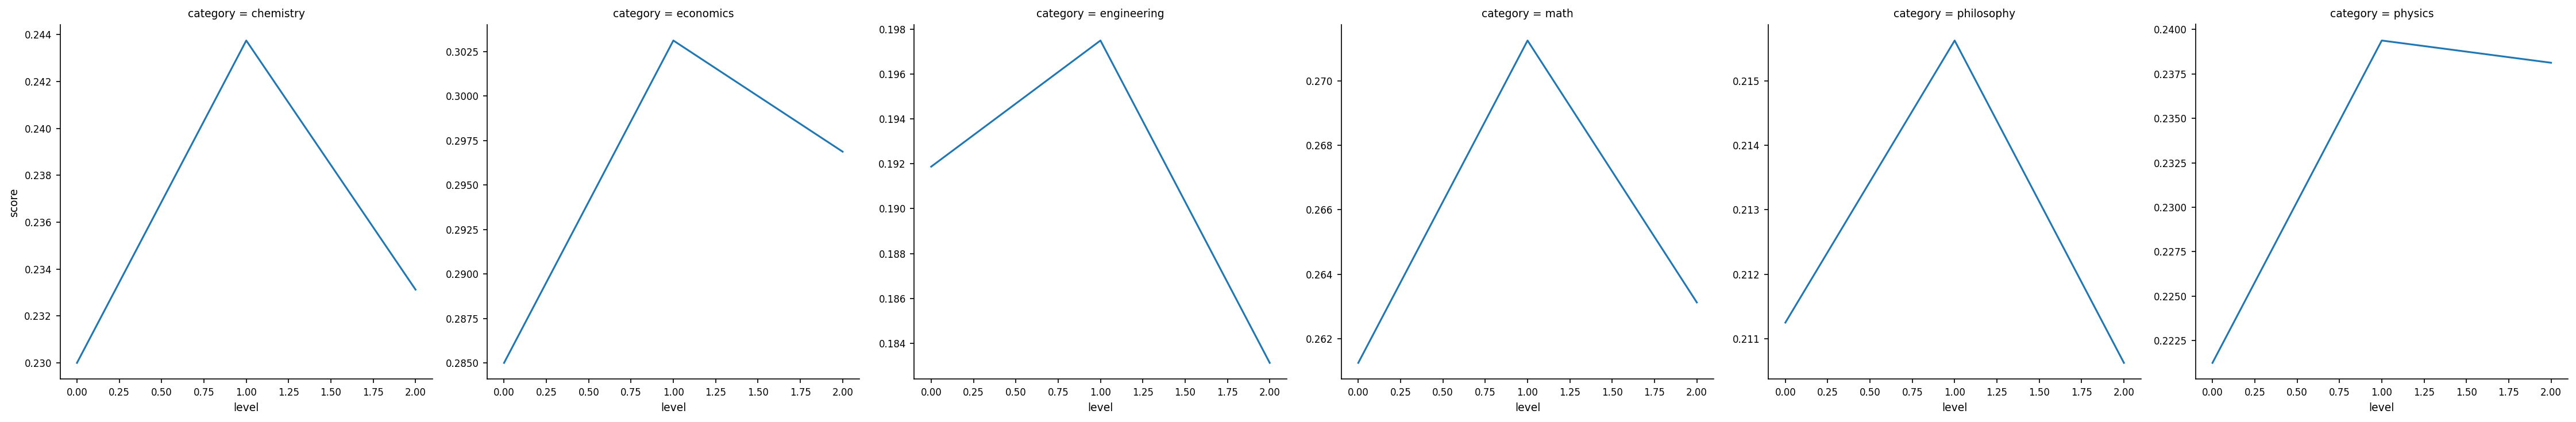

In [53]:
t_cat_df = teacher_df.groupby(["dataset", "category", "level"], as_index=False)["score"].mean()

facet_kw = {"sharey": False}
t_cat_df = t_cat_df.dropna()
for dataset, group_df in t_cat_df.groupby("dataset"):
    sns.relplot(group_df, x="level", y="score", col="category", kind="line", facet_kws=facet_kw)

In [54]:
print_sig(tests_teacher_df, "category")

 === Algebra ===
Persona level                p-val 0.039 coef 0.148
 === Intermediate Algebra ===
 === Number Theory ===
Persona level                p-val 0.004 coef 0.327
 === Prealgebra ===
Persona level                p-val 0.034 coef 0.181
 === Precalculus ===
 === ace ===
Persona level                p-val 0.000 coef 0.201
 === chemistry ===
 === cmn ===
Persona level                p-val 0.000 coef 0.625
 === deu ===
Persona level                p-val 0.000 coef 0.685
 === economics ===
 === engineering ===
 === math ===
 === philosophy ===
 === physics ===
 === spa ===
Persona level                p-val 0.000 coef 0.633
 === swh ===
Persona level                p-val 0.000 coef 0.422


# 4. Static vs. Dynamic

In [59]:
from evaluate import prepare_static_vs_dynamic

dynamic_df = prepare_static_vs_dynamic(length_base_df)

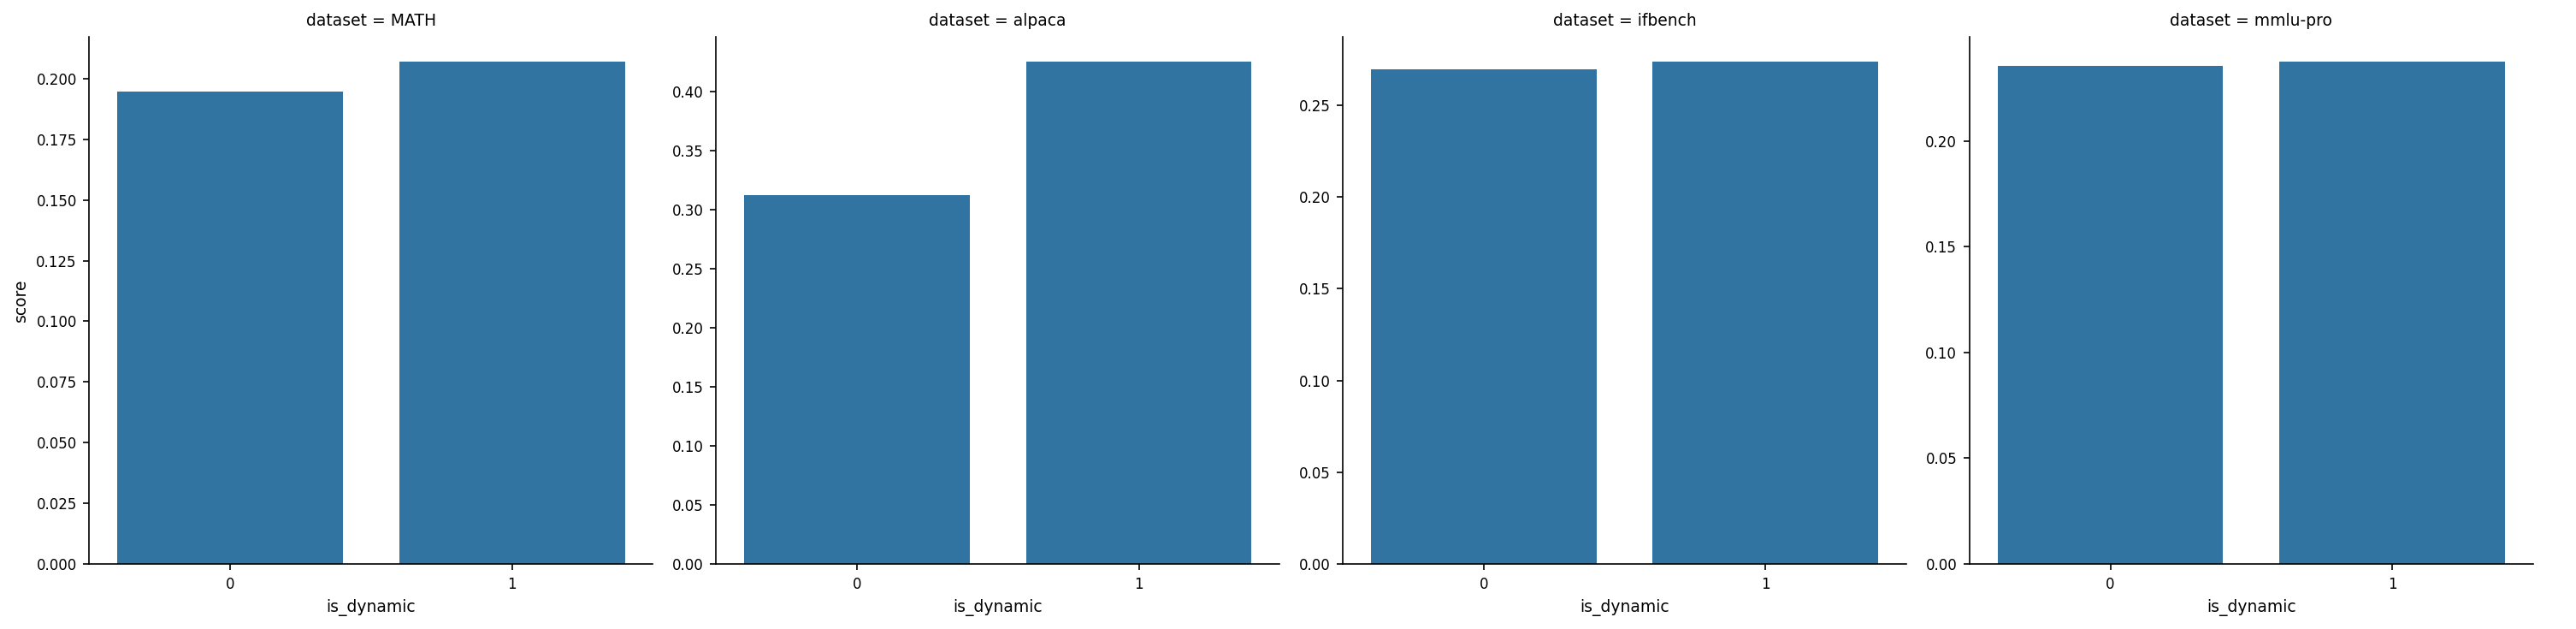

In [65]:
d_dynamic_df = dynamic_df.groupby(["dataset", "is_dynamic"], as_index=False)["score"].mean()
sns.catplot(d_dynamic_df, col="dataset", y="score", kind="bar", x="is_dynamic", orient="v", sharey=False)

In [67]:
dataset_dynamic_results = tests_dynamic_df[tests_dynamic_df["category"].isna()]
print_sig(dataset_dynamic_results, "dataset")

 === MATH ===
Persona is_dynamic           p-val 0.004 coef 0.134
 === alpaca ===
Persona is_dynamic           p-val 0.000 coef 0.112
 === flores ===
Persona is_dynamic           p-val 0.000 coef 0.254
 === ifbench ===
 === mmlu-pro ===


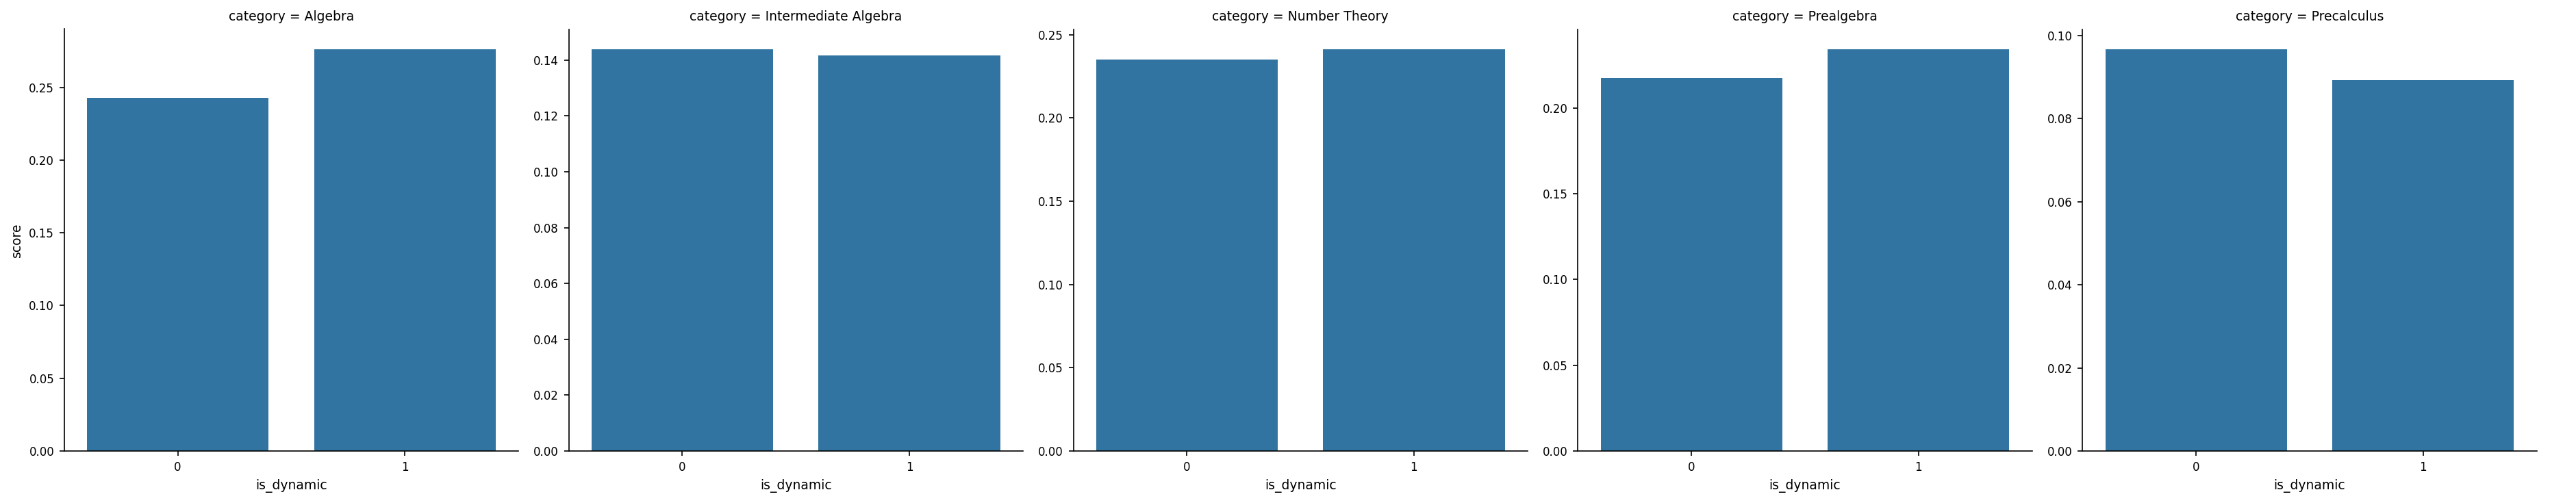

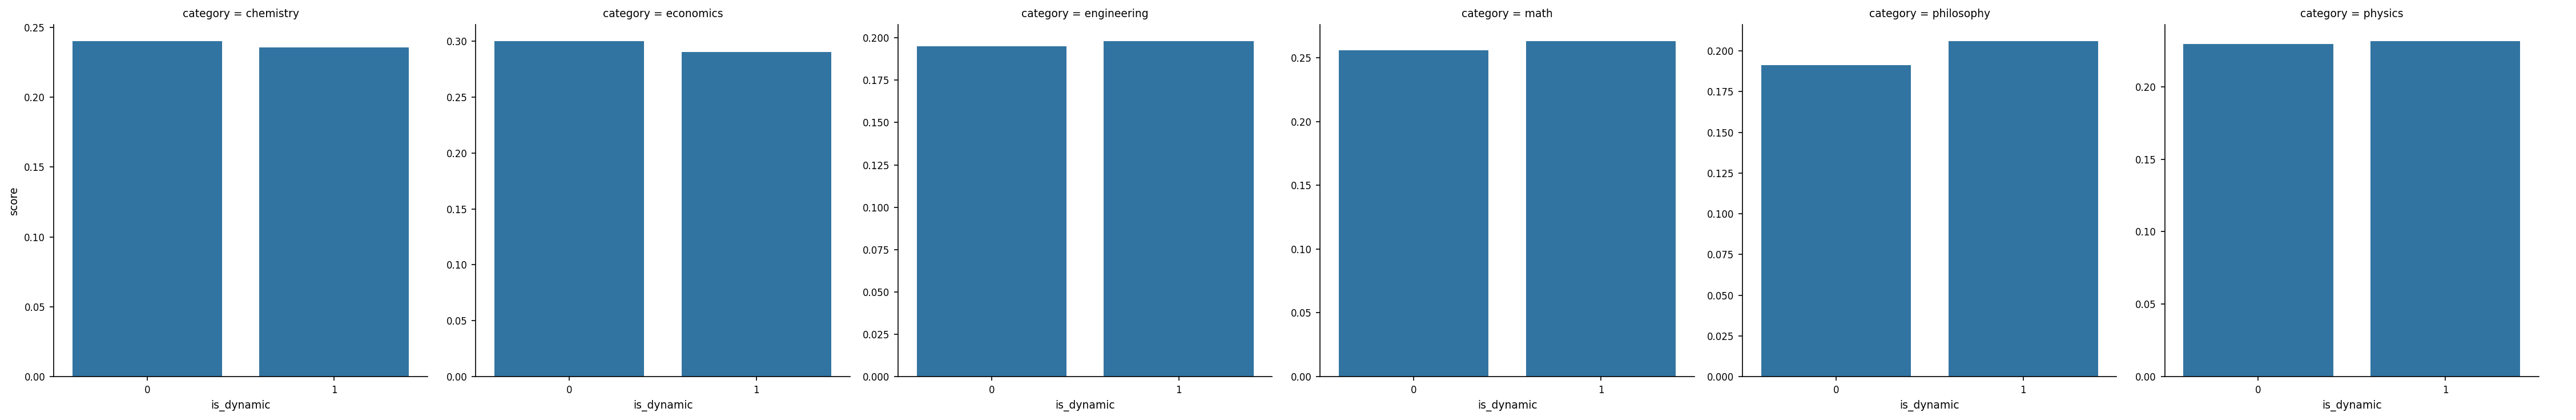

In [78]:
dynamic_cat_df = dynamic_df.groupby(["dataset", "category", "is_dynamic"], as_index=False)["score"].mean()
for dataset, dynamic_group_df in dynamic_cat_df.groupby("dataset"):
    sns.catplot(dynamic_group_df, col="category", x="is_dynamic", y="score", kind="bar", sharey=False)

In [82]:
print_sig(tests_dynamic_df, "category")

 === Algebra ===
Persona is_dynamic           p-val 0.000 coef 0.362
 === Intermediate Algebra ===
 === Number Theory ===
 === Prealgebra ===
 === Precalculus ===
 === ace ===
Persona is_dynamic           p-val 0.001 coef 0.133
 === chemistry ===
 === cmn ===
Persona is_dynamic           p-val 0.000 coef 0.267
 === deu ===
Persona is_dynamic           p-val 0.000 coef 0.265
 === economics ===
 === engineering ===
 === math ===
 === philosophy ===
Persona is_dynamic           p-val 0.036 coef 0.124
 === physics ===
 === spa ===
Persona is_dynamic           p-val 0.000 coef 0.202
 === swh ===
Persona is_dynamic           p-val 0.000 coef 0.416


## Create plots

In [37]:
plotting_wrapper.create_accuracy_plots("mmlu-pro", category_col="category")
plotting_wrapper.create_accuracy_plots("MATH", category_col="subject")
plotting_wrapper.create_accuracy_plots("ifbench")

In [25]:
plotting_wrapper.create_stacked_barchart_plots("alpaca", "")
plotting_wrapper.create_stacked_barchart_plots("flores", category_col="iso_639_3")